In [1]:
!pip install pyupbit

>>> 1. 업비트 15분봉 데이터 수집 중 (최근 2000개 캔들)...
>>> 2. AI 모델 학습 시작...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



>>> 3. 실전: 다음 15분 예측 분석...
--------------------------------------------------
⏰ 현재 시간: 2026-07-07 22:00:00
💰 현재 가격: 95,005,000 KRW
🎯 15분 뒤 예상 가격: 94,994,932 KRW (예상 변동: -0.011%)
--------------------------------------------------


/tmp/ipykernel_1789/26434329.py:144: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


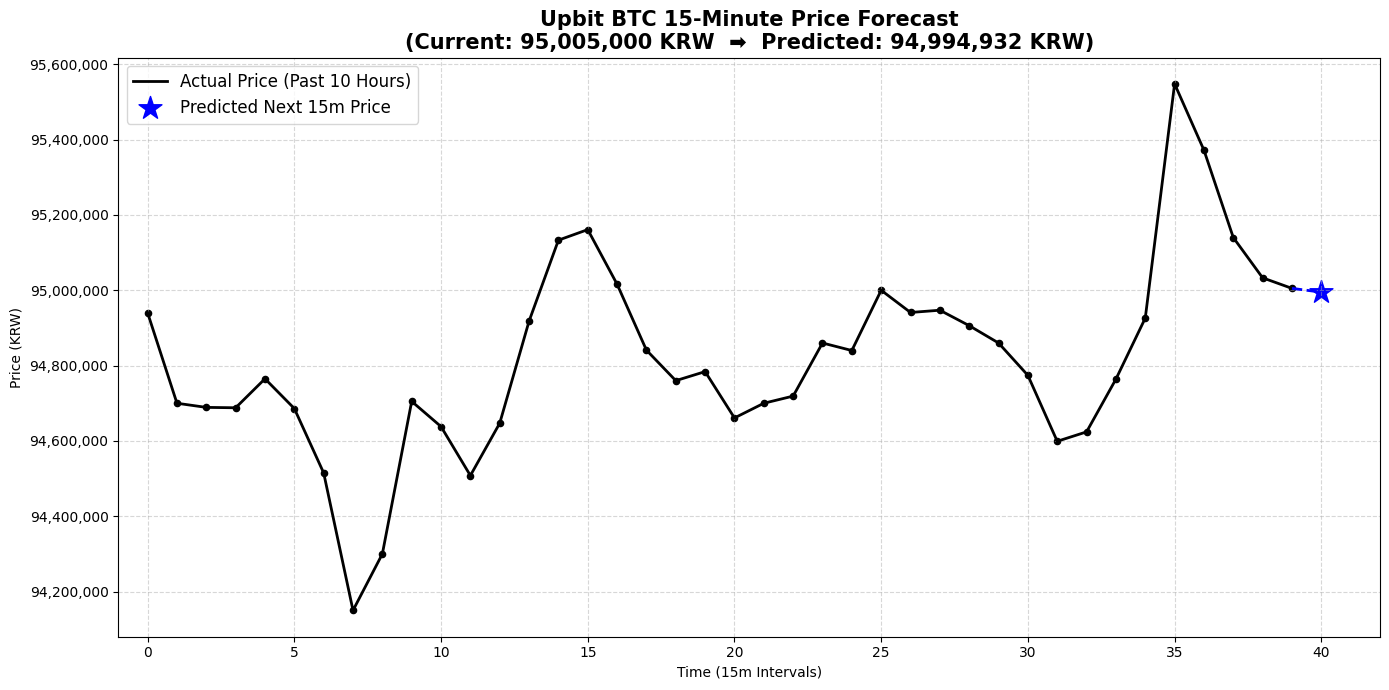

In [4]:
# !pip install pyupbit

import os
import pyupbit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam

os.makedirs('./data/model/', exist_ok=True)

# ==========================================
# 1. 15분봉 실시간 데이터 수집 (실제 가격 보존 추가)
# ==========================================
def fetch_15m_data():
    print(">>> 1. 업비트 15분봉 데이터 수집 중 (최근 2000개 캔들)...")
    df = pyupbit.get_ohlcv("KRW-BTC", interval="minute15", count=2000)

    # 지표 생성
    df['Return_15m'] = df['close'].pct_change() * 100
    df['Volume'] = df['volume']
    df['Volatility'] = ((df['high'] - df['low']) / df['low']) * 100

    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI_14'] = 100 - (100 / (1 + rs))

    # [수정됨] 나중에 차트를 그리기 위해 'close' 가격을 'BTC_Price'로 함께 남겨둡니다.
    final_df = df[['close', 'Return_15m', 'Volume', 'Volatility', 'RSI_14']].dropna()
    final_df = final_df.rename(columns={'close': 'BTC_Price'})
    return final_df

df = fetch_15m_data()

# ==========================================
# 2. 데이터 전처리 및 스케일링
# ==========================================
target_col = 'Return_15m'
# AI 학습에는 가격(BTC_Price)을 빼고, 등락률과 수급 지표만 넣습니다.
feature_cols = ['Return_15m', 'Volume', 'Volatility', 'RSI_14']

X_scaler = StandardScaler()
y_scaler = StandardScaler()

scaled_X_data = X_scaler.fit_transform(df[feature_cols])
scaled_y_data = y_scaler.fit_transform(df[[target_col]])

# ==========================================
# 3. 슬라이딩 윈도우 변환
# ==========================================
window_size = 12
X, y = [], []

for i in range(len(scaled_X_data) - window_size):
    X.append(scaled_X_data[i : i + window_size])
    y.append(scaled_y_data[i + window_size][0])

X, y = np.array(X), np.array(y)

test_size = int(len(X) * 0.1)
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

# ==========================================
# 4. 모델 학습
# ==========================================
print(">>> 2. AI 모델 학습 시작...")
model = Sequential()
num_features = len(feature_cols)

model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(window_size, num_features)))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(50, activation='relu', return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(30, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
callbacks = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)]

history = model.fit(X_train, y_train, validation_split=0.1, epochs=100, batch_size=32, callbacks=callbacks, verbose=0)

# ==========================================
# 5. 실시간 "다음 15분" 가격 예측
# ==========================================
print("\n>>> 3. 실전: 다음 15분 예측 분석...")
recent_12_candles = scaled_X_data[-window_size:]
X_predict = np.expand_dims(recent_12_candles, axis=0)

# 등락률(%) 예측
scaled_prediction = model.predict(X_predict, verbose=0)
final_prediction_percent = y_scaler.inverse_transform(scaled_prediction)[0][0]

# [핵심] 현재 가격에 예측 등락률을 곱해서 '다음 15분 뒤의 예상 원화 가격'을 계산합니다.
current_price = df['BTC_Price'].iloc[-1]
predicted_next_price = current_price * (1 + (final_prediction_percent / 100))

print("-" * 50)
print(f"⏰ 현재 시간: {df.index[-1]}")
print(f"💰 현재 가격: {current_price:,.0f} KRW")
print(f"🎯 15분 뒤 예상 가격: {predicted_next_price:,.0f} KRW (예상 변동: {final_prediction_percent:.3f}%)")
print("-" * 50)

# ==========================================
# 6. [시각화] 실전 매매 차트처럼 그리기
# ==========================================
# 최근 40개 캔들(10시간 분량)의 실제 가격 흐름을 가져옵니다.
past_prices = df['BTC_Price'].iloc[-40:].values
time_labels = df.index[-40:]

plt.figure(figsize=(14, 7))

# 1. 과거 실제 가격 차트 그리기 (검은색 실선)
plt.plot(range(len(past_prices)), past_prices, color='black', linewidth=2, label='Actual Price (Past 10 Hours)')
plt.scatter(range(len(past_prices)), past_prices, color='black', s=20)

# 2. 다음 15분 예측 가격 선 그리기
# 예측선 색상 결정 (상승 예상=빨간색(한국차트 기준), 하락 예상=파란색)
pred_color = 'red' if predicted_next_price > current_price else 'blue'

# 마지막 실제 가격에서 예측 가격으로 이어지는 점선
plt.plot([len(past_prices)-1, len(past_prices)],
         [current_price, predicted_next_price],
         color=pred_color, linestyle='--', linewidth=2)

# 예측 목표가에 눈에 띄는 마커(별모양) 찍기
plt.scatter(len(past_prices), predicted_next_price, color=pred_color, marker='*', s=300, label='Predicted Next 15m Price')

# 차트 꾸미기
plt.title(f'Upbit BTC 15-Minute Price Forecast\n(Current: {current_price:,.0f} KRW  ➡  Predicted: {predicted_next_price:,.0f} KRW)', fontsize=15, fontweight='bold')
plt.xlabel('Time (15m Intervals)')
plt.ylabel('Price (KRW)')

# 가격 천 단위 콤마 포맷팅
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# 차트 우측 빈 공간(미래)을 약간 더 늘려줌
plt.xlim(-1, len(past_prices) + 2)
plt.tight_layout()
plt.show()